# Final GT_OK Segmentation Audit

Bản final này dùng GT_OK làm điểm neo chính, vì metric trên pseudo-label test chỉ đo mức độ mô hình học lại nhãn giả, không đo đúng chất lượng segmentation thật.

## Kết quả tổng hợp

| version | name | model | gt_pred_iou | gt_pred_dice | gt_pred_precision | gt_pred_recall | pseudo_gt_available_iou | pseudo_gt_available_dice | pseudo_gt_available_recall | pseudo_available | pseudo_missing | pseudo_test_iou | pseudo_test_dice |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| V1 | Grad-CAM + U-Net baseline | EfficientNet encoder U-Net | 0.2169 | 0.3565 | 0.2460 | 0.6472 | 0.2185 | 0.3586 | 0.6466 | 44 | 36 | 0.8126 | 0.8813 |
| V2 | Grad-CAM++ + U-Net++ | segmentation_models_pytorch UnetPlusPlus | 0.1972 | 0.3294 | 0.2459 | 0.4987 | 0.1706 | 0.2914 | 0.3805 | 40 | 40 | 0.5088 | 0.6181 |
| V3 | SAM refinement diagnostic | U-Net++ trained on SAM-refined pseudo masks | 0.1351 | 0.2381 | 0.1409 | 0.7685 | 0.1544 | 0.2675 | 0.7388 | 40 | 40 | 0.6781 | 0.7567 |
| V5 | Color-prior pseudo-labels + segmentation | U-Net++ trained on color-prior pseudo masks | 0.2183 | 0.3583 | 0.2358 | 0.7455 | 0.1989 | 0.3317 | 0.6500 | 40 | 40 | 0.5084 | 0.6030 |

## Xếp hạng theo GT_OK prediction IoU

1. V5 - Color-prior pseudo-labels + segmentation: IoU 0.2183, Dice 0.3583, Precision 0.2358, Recall 0.7455.
2. V1 - Grad-CAM + U-Net baseline: IoU 0.2169, Dice 0.3565, Precision 0.2460, Recall 0.6472.
3. V2 - Grad-CAM++ + U-Net++: IoU 0.1972, Dice 0.3294, Precision 0.2459, Recall 0.4987.
4. V3 - SAM refinement diagnostic: IoU 0.1351, Dice 0.2381, Precision 0.1409, Recall 0.7685.

## Nhận xét cuối

Quan sát chính: sau khi rerun notebook 06-11, V5 đạt GT_OK prediction IoU cao nhất (0.2183), V1 baseline đứng rất sát phía sau (0.2169), V2 giảm còn 0.1972, còn V3 thấp nhất (0.1351). Chênh lệch V5 và V1 rất nhỏ, vì vậy kết luận nên nhấn mạnh xu hướng cải thiện của hướng color-prior hơn là một thắng lợi tuyệt đối.

Đánh giá: V5/color-prior đạt Dice 0.3583 và recall 0.7455 trên GT_OK, cho thấy mô hình bắt được vùng bệnh rộng hơn V2 nhưng precision còn thấp (0.2358). V3/SAM có recall cao nhất nhưng precision rất thấp, nghĩa là mask bị lan rộng vào nền/lá vẫn là vấn đề chính. V2 có precision tốt hơn V5 nhưng recall thấp hơn, dẫn tới IoU tổng thể thấp hơn sau rerun.

Rủi ro: Pseudo-test IoU/Dice cao không đáng tin làm metric chính vì target ở đó là pseudo-label. Ngoài ra GT_OK chỉ có 80 ảnh và mỗi version chỉ có một phần ảnh có pseudo-label train tương ứng (V1: 44, V2/V3/V5: 40), nên pseudo-vs-GT cần đọc theo available-only, không trộn với ảnh thiếu pseudo như mask rỗng.

Hàm ý cho mô hình segmentation: Chuyển từ Grad-CAM sang Grad-CAM++ và từ U-Net sang U-Net++ không tự giải quyết bottleneck. Vấn đề lớn nhất vẫn là nhãn giả: CAM/Grad-CAM++ có thể thiếu vùng bệnh, SAM làm quá rộng, còn color prior giúp cân bằng recall nhưng precision vẫn hạn chế.

Cải thiện đề xuất: Chọn V5 làm hướng refinement đáng theo tiếp, nhưng cần fine-tune/validate bằng GT subset, lọc pseudo-label theo quality gate từng class, cân lại threshold theo GT_OK, và bổ sung nhãn thủ công thật để giảm phụ thuộc vào pseudo-label.

## Kết luận sử dụng

Nếu buộc chọn theo checkpoint sau rerun: V5 là biến thể tốt nhất theo GT_OK prediction IoU, nhưng chỉ nhỉnh hơn V1 rất nhỏ và chưa đủ chất lượng để coi là production segmentation. Khi viết luận văn, nên trình bày V5 như hướng cải tiến có cơ sở thực nghiệm, đồng thời nêu rõ giới hạn do pseudo-label và quy mô GT_OK còn nhỏ.

## Artifact

- CSV: `notebooks\models\final_gt_ok_audit\final_gt_ok_segmentation_summary.csv`
- JSON: `notebooks\models\final_gt_ok_audit\final_gt_ok_segmentation_report.json`
- Biểu đồ: `visualizations\final_gt_ok_audit\final_gt_ok_comparison.png`
- Notebook tóm tắt: `notebooks\11-final-segmentation-gtok-comparison.ipynb`


,version,name,model,checkpoint_note,gt_pred_iou,gt_pred_dice,gt_pred_precision,gt_pred_recall,gt_pred_pixel_accuracy,pseudo_gt_all_iou,...,pseudo_gt_available_iou,pseudo_gt_available_dice,pseudo_gt_available_precision,pseudo_gt_available_recall,pseudo_available,pseudo_missing,pseudo_test_iou,pseudo_test_dice,pseudo_test_precision,pseudo_test_recall
0,V1,Grad-CAM + U-Net baseline,EfficientNet encoder U-Net,baseline checkpoint,0.216889,0.356464,0.245974,0.647170,NaN,0.171572,...,0.218454,0.358576,0.248067,0.646640,44,36,0.812613,0.881306,0.885090,0.909119
1,V2,Grad-CAM++ + U-Net++,segmentation_models_pytorch UnetPlusPlus,"rerun checkpoint, best validation IoU at epoch 22",0.197158,0.329376,0.245899,0.498661,0.881036,0.123668,...,0.170552,0.291405,0.236100,0.380543,40,40,0.508845,0.618147,0.630212,0.695154
2,V3,SAM refinement diagnostic,U-Net++ trained on SAM-refined pseudo masks,"rerun checkpoint, best validation IoU at epoch 14",0.135138,0.238100,0.140874,0.768470,NaN,0.131203,...,0.154397,0.267494,0.163313,0.738787,40,40,0.678090,0.756697,0.772330,0.866405
3,V5,Color-prior pseudo-labels + segmentation,U-Net++ trained on color-prior pseudo masks,"rerun checkpoint, best validation IoU at epoch 28",0.218252,0.358303,0.235821,0.745508,NaN,0.157972,...,0.198853,0.331739,0.222701,0.649982,40,40,0.508372,0.602989,0.666540,0.668694


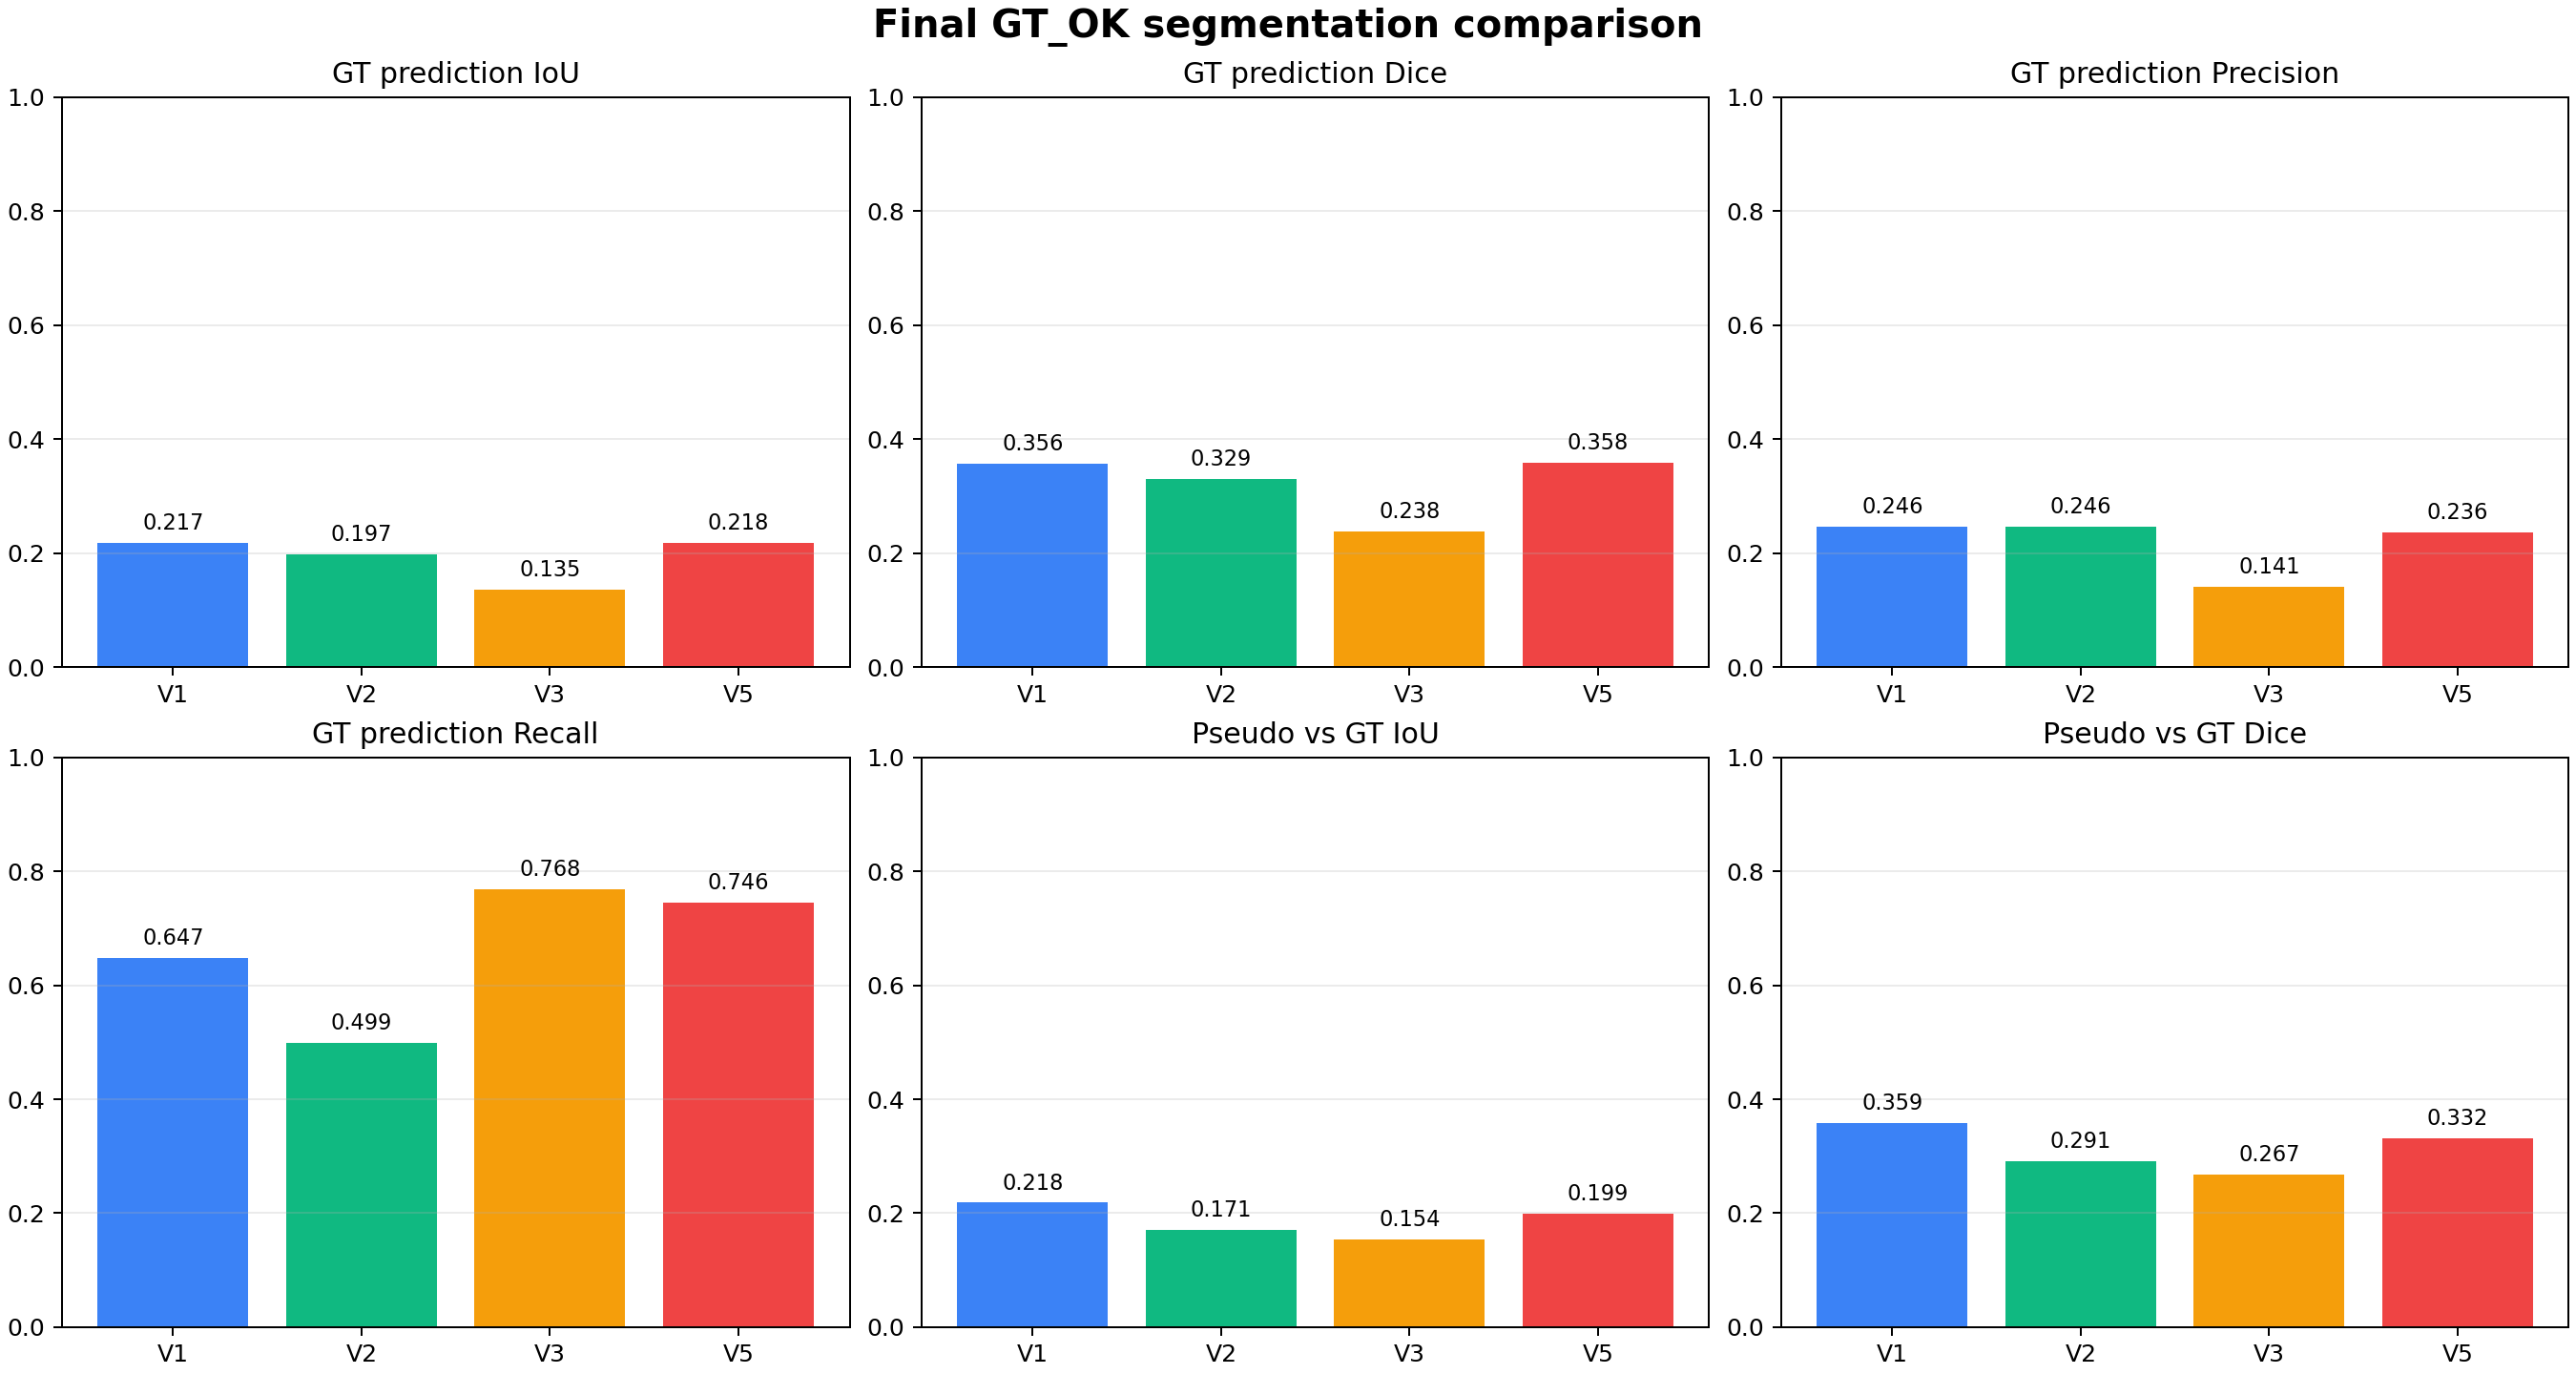

In [1]:
import pandas as pd
from IPython.display import display, Image

summary = pd.read_csv('models/final_gt_ok_audit/final_gt_ok_segmentation_summary.csv')
display(summary)
Image('../visualizations/final_gt_ok_audit/final_gt_ok_comparison.png')


<!-- codex-rerun-note-2026-08-30 -->

## Nhận xét sau rerun 30/08/2026

GT_OK được dùng làm điểm neo chính vì pseudo-test đo khả năng học lại nhãn giả. Xếp hạng theo GT_OK prediction IoU sau rerun:

1. **V5**: IoU 0.2183, Dice 0.3583, Precision 0.2358, Recall 0.7455
2. **V1**: IoU 0.2169, Dice 0.3565, Precision 0.2460, Recall 0.6472
3. **V2**: IoU 0.1972, Dice 0.3294, Precision 0.2459, Recall 0.4987
4. **V3**: IoU 0.1351, Dice 0.2381, Precision 0.1409, Recall 0.7685

Kết luận thực nghiệm: V5/color-prior là biến thể tốt nhất theo IoU GT_OK nhưng chỉ nhỉnh hơn V1 rất nhỏ; V3 có recall cao nhưng precision thấp, thể hiện lỗi mask lan rộng. Vì vậy luận văn nên báo cáo V5 như hướng cải tiến có triển vọng, đồng thời nêu rõ giới hạn do nhãn giả và tập GT_OK chỉ gồm 80 ảnh.

## Bổ sung sau notebook 12: kiểm chứng cấu hình final

Notebook 11 chỉ ra ưu/nhược điểm của từng checkpoint: V3/SAM có recall cao nhưng precision thấp, V5/color-prior là checkpoint đơn lẻ tốt nhất nhưng chỉ nhỉnh hơn V1. Từ nhận xét đó, notebook 12 thử nghiệm cấu hình final dạng hậu xử lý/fusion:

- Ứng viên tốt nhất theo holdout: `FINAL_V2_V3_V5_fusion`.
- Thiết kế: fusion xác suất V2/V3/V5, tune threshold và coverage cap theo lớp trên 40 ảnh GT_OK, đánh giá trên 40 ảnh holdout còn lại.
- Holdout GT_OK: IoU `0.3076`, Dice `0.4705`, Precision `0.4311`, Recall `0.5178`.
- Full GT_OK: IoU `0.3083`, Dice `0.4713`, Precision `0.4128`, Recall `0.5492`.

Kết quả này cải thiện rõ so với checkpoint đơn lẻ tốt nhất V5 (full GT_OK IoU 0.2183). Tuy vậy, vì tham số final được tune trên một phần GT_OK, kết luận học thuật đúng mức là: đây là bằng chứng thực nghiệm ban đầu cho hướng fusion/prior có kiểm soát, chưa phải ước lượng hiệu năng cuối cùng trên tập kiểm thử độc lập lớn.